# Inference Recorder Review
This notebook is focused on visually checking what the inference recorder is saving.
It is intentionally exploratory and tolerant to partial runs.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebooks.review_utils import (
    PROJECT_ROOT,
    discover_recorder_payloads,
    list_recorder_files,
    extract_decoder_deformable_attention,
    load_recorder_payload,
    resolve_image_bank_path,
    payload_summary_frame,
    activation_inventory_frame,
    decoder_attention_summary_frame,
    plot_scanpath_overview,
    plot_attention_heatmap,
    plot_sampling_locations,
    plot_decoder_deformable_attention_overlay,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
PROJECT_ROOT

WindowsPath('C:/Users/ulloa/.codex/worktrees/b9cf/From-Noisy-Eye-Tracking-To-Scanpath')

In [2]:
all_pt_files = list_recorder_files()
display(all_pt_files.head(20))

recorder_files = discover_recorder_payloads(limit=50)
display(recorder_files)

if recorder_files.empty:
    print('No inference-recorder payloads were found yet. Once a run produces *.pt payloads, re-run this notebook.')

""


""


No inference-recorder payloads were found yet. Once a run produces *.pt payloads, re-run this notebook.


In [3]:
selected_path = None
if not recorder_files.empty:
    selected_path = PROJECT_ROOT / recorder_files.iloc[0]['file']
selected_path

## Decoder Deformable Attention Overlay
This section is focused on `decoder.#.second_cross_attn` only.
The origin is reconstructed from teacher-forced fixation coordinates, so query `0` starts at `(0.5, 0.5)` and later queries start at the previous ground-truth fixation.
The `eye_decoder.#.cross_attn` branch is intentionally left out for this iteration.

In [4]:
external_record_dir = Path(r'C:\Users\ulloa\Miooooo\Master\thesis\projectes\From-Noisy-Eye-Tracking-To-Scanpath\outputs\outputs\2026-03-16\18-24-45\inference_records')
external_candidates = sorted(external_record_dir.glob('*.pt')) if external_record_dir.exists() else []
payload_path = external_candidates[-1] if external_candidates else selected_path
sample_index = 0
decoder_layer = 3
query_index = 3
aggregate_heads = False
head_index = None
image_bank_path = None

payload_path

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath/outputs/outputs/2026-03-16/18-24-45/inference_records/val_epoch_0140_batch_00054_Combined.pt')

In [5]:
payload = None
if payload_path is not None:
    payload = load_recorder_payload(payload_path)
    display(payload.get('metadata', {}))
    display(payload_summary_frame(payload))
    try:
        resolved_image_bank_path = resolve_image_bank_path(payload_path=payload_path, image_bank_path=image_bank_path)
        print('image_bank_path =', resolved_image_bank_path)
    except FileNotFoundError as exc:
        resolved_image_bank_path = None
        print(exc)

{'epoch': 140,
 'phase': 'Combined',
 'split': 'val',
 'batch_index': 54,
 'global_step': None,
 'model_name': 'MixerModel'}

,section,name,shape,dtype
0,data,sample_idx,"(15,)",torch.int64
1,data,image_idx,"(15,)",torch.int64
2,data,eye_tracking_input,"(15, 13, 3)",torch.float32
3,data,fixation_ground_truth,"(15, 10, 3)",torch.float32
4,outputs,denoise_output,"(15, 13, 2)",torch.float32
5,outputs,scanpath_coordinates,"(15, 11, 2)",torch.float32
6,outputs,scanpath_duration,"(15, 11, 1)",torch.float32
7,outputs,scanpath_end_logits,"(15, 11, 1)",torch.float32
8,activations,eye_decoder.0.cross_attn.sampling_offsets,"(15, 13, 8, 4, 2)",list
9,activations,eye_decoder.0.cross_attn.attention_weights,"(15, 13, 8, 4)",list


image_bank_path = C:\Users\ulloa\Miooooo\Master\thesis\projectes\From-Noisy-Eye-Tracking-To-Scanpath\data\Coco FreeView\all_images_256.pth


In [6]:
decoder_attention_info = None
if payload is not None:
    decoder_attention_info = extract_decoder_deformable_attention(
        payload,
        sample_index=sample_index,
        decoder_layer=decoder_layer,
        query_index=query_index,
        aggregate_heads=aggregate_heads,
        head_index=head_index,
    )
    display({
        'module_name': decoder_attention_info['module_name'],
        'query_count': decoder_attention_info['query_count'],
        'num_heads': decoder_attention_info['num_heads'],
        'num_points': decoder_attention_info['num_points'],
        'valid_fixation_count': decoder_attention_info['valid_fixation_count'],
        'is_terminal_or_padded': decoder_attention_info['is_terminal_or_padded'],
        'selected_head_index': decoder_attention_info['selected_head_index'],
    })
    display(decoder_attention_summary_frame(
        payload,
        sample_index=sample_index,
        decoder_layer=decoder_layer,
        query_index=query_index,
        aggregate_heads=aggregate_heads,
        head_index=head_index,
    ))

SAMPLING LOCATIONS
<class 'list'>
11
torch.Size([15, 1, 8, 4, 2])
torch.Size([15, 2, 8, 4, 2])
torch.Size([15, 3, 8, 4, 2])
torch.Size([15, 4, 8, 4, 2])
torch.Size([15, 5, 8, 4, 2])
torch.Size([15, 6, 8, 4, 2])
torch.Size([15, 7, 8, 4, 2])
torch.Size([15, 8, 8, 4, 2])
torch.Size([15, 9, 8, 4, 2])
torch.Size([15, 10, 8, 4, 2])
torch.Size([15, 11, 8, 4, 2])


{'module_name': 'decoder.3.second_cross_attn',
 'query_count': 11,
 'num_heads': 8,
 'num_points': 4,
 'valid_fixation_count': 8,
 'is_terminal_or_padded': False,
 'selected_head_index': None}

SAMPLING LOCATIONS
<class 'list'>
11
torch.Size([15, 1, 8, 4, 2])
torch.Size([15, 2, 8, 4, 2])
torch.Size([15, 3, 8, 4, 2])
torch.Size([15, 4, 8, 4, 2])
torch.Size([15, 5, 8, 4, 2])
torch.Size([15, 6, 8, 4, 2])
torch.Size([15, 7, 8, 4, 2])
torch.Size([15, 8, 8, 4, 2])
torch.Size([15, 9, 8, 4, 2])
torch.Size([15, 10, 8, 4, 2])
torch.Size([15, 11, 8, 4, 2])


,label,target_x,target_y,delta_x,delta_y,attention_weight
0,head_0_point_0,0.435918,0.314089,-0.026760,-0.178101,0.139206
1,head_0_point_1,0.509553,0.291409,0.046875,-0.200782,0.088695
2,head_0_point_2,0.498194,0.273923,0.035516,-0.218267,0.089215
3,head_0_point_3,2.257346,0.970048,1.794667,0.477857,0.682884
4,head_1_point_0,0.379221,0.472571,-0.083458,-0.019620,0.756055
5,head_1_point_1,1.169529,0.513163,0.706851,0.020972,0.013251
6,head_1_point_2,1.634144,0.021308,1.171466,-0.470882,0.034640
7,head_1_point_3,1.661677,0.738959,1.198998,0.246768,0.196054
8,head_2_point_0,0.319508,0.245545,-0.143171,-0.246646,0.024924
9,head_2_point_1,0.182858,0.329780,-0.279820,-0.162411,0.018366


SAMPLING LOCATIONS
<class 'list'>
11
torch.Size([15, 1, 8, 4, 2])
torch.Size([15, 2, 8, 4, 2])
torch.Size([15, 3, 8, 4, 2])
torch.Size([15, 4, 8, 4, 2])
torch.Size([15, 5, 8, 4, 2])
torch.Size([15, 6, 8, 4, 2])
torch.Size([15, 7, 8, 4, 2])
torch.Size([15, 8, 8, 4, 2])
torch.Size([15, 9, 8, 4, 2])
torch.Size([15, 10, 8, 4, 2])
torch.Size([15, 11, 8, 4, 2])


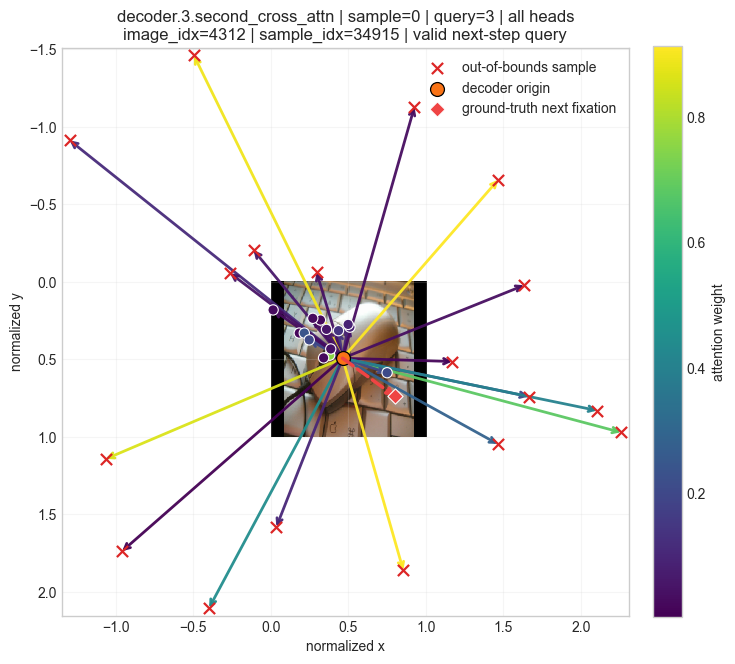

In [7]:
if payload is not None:
    plot_decoder_deformable_attention_overlay(
        payload,
        sample_index=sample_index,
        decoder_layer=decoder_layer,
        query_index=query_index,
        aggregate_heads=aggregate_heads,
        head_index=head_index,
        payload_path=payload_path,
        image_bank_path=image_bank_path,
    )

In [8]:
if payload is not None:
    display(activation_inventory_frame(payload).sort_values(['module', 'activation']).reset_index(drop=True))

,module,activation,shape,captures
0,decoder.0.first_cross_attn,attention_weights,"(15, 8, 1, 13)",11
1,decoder.0.second_cross_attn,attention_weights,"(15, 1, 8, 4)",11
2,decoder.0.second_cross_attn,sampling_locations,"(15, 1, 8, 4, 2)",11
3,decoder.0.second_cross_attn,sampling_offsets,"(15, 1, 8, 4, 2)",11
4,decoder.1.first_cross_attn,attention_weights,"(15, 8, 1, 13)",11
5,decoder.1.second_cross_attn,attention_weights,"(15, 1, 8, 4)",11
6,decoder.1.second_cross_attn,sampling_locations,"(15, 1, 8, 4, 2)",11
7,decoder.1.second_cross_attn,sampling_offsets,"(15, 1, 8, 4, 2)",11
8,decoder.2.first_cross_attn,attention_weights,"(15, 8, 1, 13)",11
9,decoder.2.second_cross_attn,attention_weights,"(15, 1, 8, 4)",11


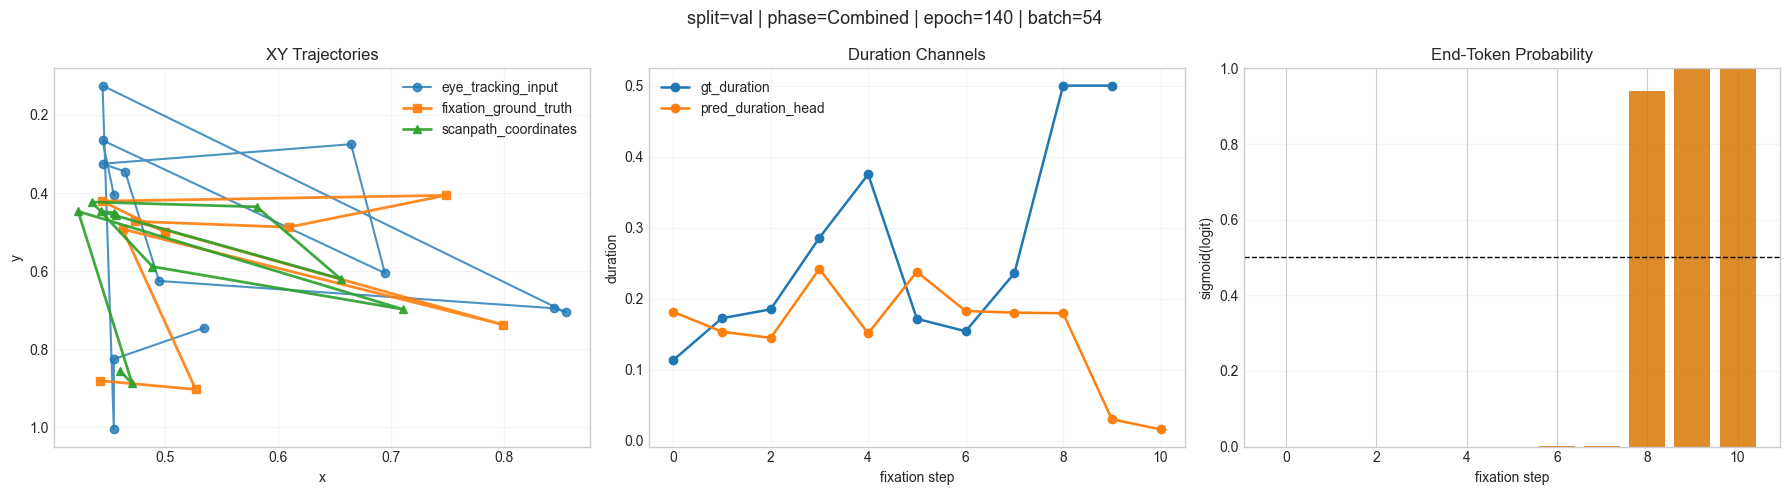

In [9]:
if payload is not None:
    plot_scanpath_overview(payload, sample_index=sample_index)

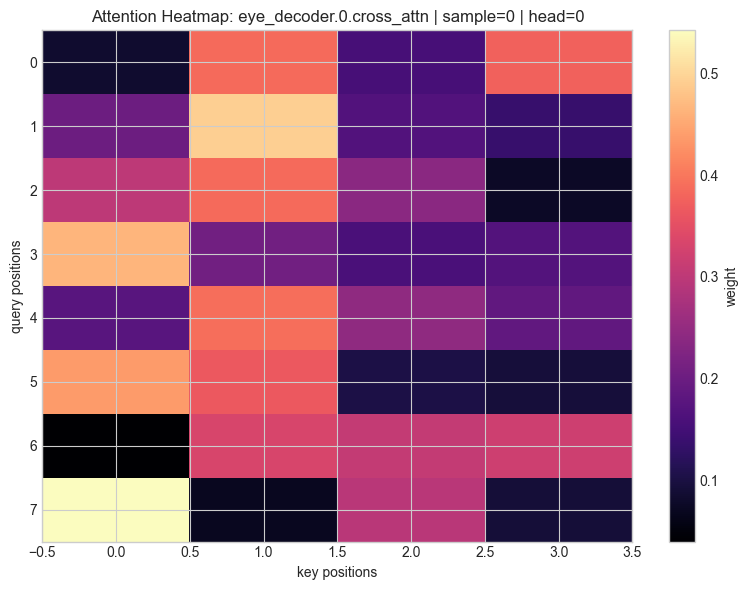

In [10]:
if payload is not None:
    try:
        plot_attention_heatmap(payload, sample_index=sample_index, head_index=0)
    except ValueError as exc:
        print(exc)

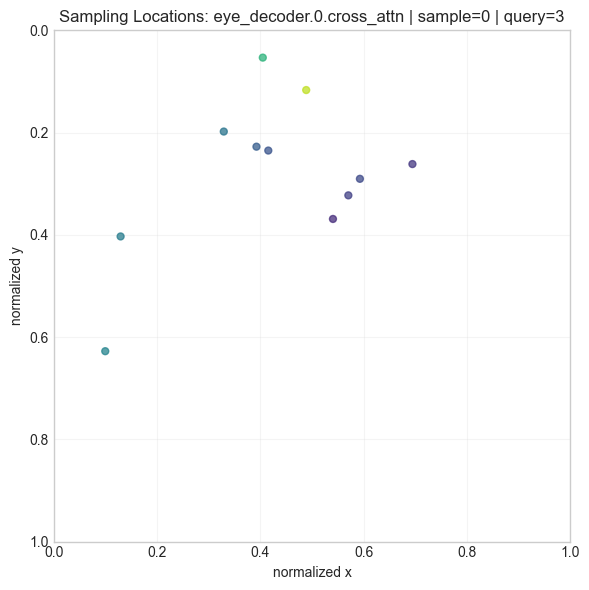

In [11]:
if payload is not None:
    try:
        plot_sampling_locations(payload, sample_index=sample_index, query_index=query_index)
    except ValueError as exc:
        print(exc)

## Notes
- `data` comes from `InferenceRecorder.record_batch` and currently includes indices plus input/target tensors when present.
- `outputs` includes `denoise`, `coord`, `dur`, `reg`, and `cls` under more descriptive names.
- `activations` currently come from attention modules in `blocks.py`, mainly cross-attention weights and deformable-attention sampling tensors.